In [1]:
# ==========================================
# 1. PREPARACIÓ DE L'ENTORN MODERN
# ==========================================
using Pkg
Pkg.activate("/home/antonibancells/Desktop/Codi/TFM/ProvesModernes")

  Activating project at `~/Desktop/Codi/TFM/ProvesModernes`


In [2]:
#Librerías necesarias
using ITensors
using ITensorMPS
using Plots
using LinearAlgebra
using SpecialFunctions
using LegendrePolynomials

In [3]:
#Función genérica para construir polinomio en qtt
function construir_polinomio_qtt(sites, x_min,dx, coeficientes)
    N = length(sites)
    chi = length(coeficientes) # La dimensión virtual se ajusta al grado del polinomio + 1
    
    b = MPS(sites)
    blinks = [Index(chi, "link,l=$i") for i in 1:(N-1)]
    
    # --- NODO 1: Inicialización de la base ---
    b[1] = ITensor(sites[1], blinks[1])
    for s in 1:2
        c = (s == 1) ? 0.0 : dx * 2.0^0
        for j in 1:chi
            b[1][sites[1]=>s, blinks[1]=>j] =(x_min+c)^(j-1)
        end
    end

    # --- BULK UNIVERSAL: Matriz de transferencia de Pascal ---
    for k in 2:(N-1)
        b[k] = ITensor(blinks[k-1], sites[k], blinks[k])
        val_bit = dx * 2.0^(k-1)
        for s in 1:2
            c = (s == 1) ? 0.0 : val_bit
            for i in 1:chi
                for j in i:chi
                    b[k][blinks[k-1]=>i, sites[k]=>s, blinks[k]=>j] = binomial(j-1, i-1) * c^(j-i)
                end
            end
        end
    end

    # --- NODO N: Inyección de la física/matemática externa ---
    b[N] = ITensor(blinks[N-1], sites[N])
    val_bit = dx * 2.0^(N-1)
    for s in 1:2
        c = (s == 1) ? 0.0 : val_bit
        for i in 1:chi
            val_sum = 0.0
            for j in i:chi
                # Aquí inyectamos el vector externo
                val_sum += coeficientes[j] * binomial(j-1, i-1) * c^(j-i)
            end
            b[N][blinks[N-1]=>i, sites[N]=>s] = val_sum
        end
    end
    
    return b
end

construir_polinomio_qtt (generic function with 1 method)

In [4]:
# --- GENERADOR DE COEFICIENTES DE LOS POLINOMIOS DE LEGENDRE ---
# Devuelve el vector C de tamaño (n+1) para los coeficientes del polinomio P_n(x)
function coeficientes_polinomio_Legendre(n)
    # Inicializamos la matriz de coeficientes (potencia x polinomio)
    M = zeros(Float64, n + 1, n + 1)
    
    # Casos base:
    # P_0(x) = 1  -> Coeficiente de x^0 es 1
    M[1, 1] = 1.0 
    
    if n == 0
        return M[:, 1]
    end
    
    # P_1(x) = x  -> Coeficiente de x^1 es 1
    M[2, 2] = 1.0 
    
    if n == 1
        return M[:, 2]
    end
    
    # Bucle de recurrencia de Bonnet
    for k in 1:(n-1)
        alpha = (2k + 1) / (k + 1)
        beta  = k / (k + 1)
        
        # 1. Multiplicar P_k por alpha * x (desplazar hacia abajo y escalar)
        for i in 1:n
            M[i+1, k+2] = alpha * M[i, k+1]
        end
        
        # 2. Restar beta * P_{k-1}
        for i in 1:(n+1)
            M[i, k+2] -= beta * M[i, k]
        end
    end
    
    # La última columna contiene los coeficientes monomiales de P_n(x)
    return M[:, n + 1]
end

coeficientes_polinomio_Legendre (generic function with 1 method)

In [5]:
# --- PARÁMETROS DE LA MALLA ULTRA-DENSA ---
N = 20                  # 20 qubits/bits
dim_total = 1 << N      # 2^20 = 1.048.576 puntos
x_min = -1
x_max = 1  
dx = (x_max - x_min) / dim_total  

n_Legendre = 10
sites = siteinds("Qubit", N)

println("=== EXPERIMENTO QTT DE ALTA ESCALA ===")
println("Puntos en la malla: ", dim_total)
println("Número de Qubits:   ", N)
println("-"^50)

# Ejecutamos la construcción (Toma milisegundos)
println("Generando MPS comprimido directamente...")
@time mps_Legendre = construir_polinomio_qtt(sites, x_min,dx, coeficientes_polinomio_Legendre(n_Legendre))

# ==========================================================
# COMPRESIÓN NUMÉRICA DEL RESULTADO
# ==========================================================
# Le pasamos un truncamiento numérico al MPS final para ver si el 
# algoritmo puede reordenar y optimizar la base todavía más.
println("-"^50)
println("Max Bond Dim del QTT generado:   ", maxlinkdim(mps_Legendre))
mps_optimizado = truncate!(mps_Legendre; cutoff=1e-15)
println("Max Bond Dim tras optimización:  ", maxlinkdim(mps_optimizado))

# Calculamos el número de parámetros reales en memoria RAM
num_parametros_qtt = 0
for tensor in mps_optimizado
    num_parametros_qtt += dim(tensor)  # 'dim' extrae el tamaño del espacio del tensor
end

println("\n=== COMPARATIVA DE MEMORIA REAL ===")
println("Elementos Vector Clásico:     ", dim_total, " (Floats)")
println("Elementos Guardados en QTT:   ", num_parametros_qtt, " (Floats)")
println("Factor de compresión real:    ", round(dim_total / num_parametros_qtt, digits=1), "x menos RAM")

println("\n=== CONTROL DE CALIDAD 1: MUESTREO DE PUNTOS ===")

# Función modificada y segura para extraer el valor de un MPS en un índice clásico
function evaluar_mps_en_punto(mps, sites, indice_clasico)
    # Copiamos el MPS para no alterar el original durante la proyección
    mps_temp = copy(mps)
    
    for j in 1:length(mps_temp)
        # Determinamos si el bit j está en 0 (estado 1) o 1 (estado 2)
        bit_val = ((indice_clasico >> (j - 1)) & 1) + 1
        
        # Creamos un proyector local puro tipo vector (1 en la posición del bit, 0 en la otra)
        proyector = ITensor(sites[j])
        proyector[sites[j] => bit_val] = 1.0
        
        # Contraemos el nodo local del MPS con el proyector para colapsar ese qubit
        mps_temp[j] = mps_temp[j] * proyector
    end
    
    # Al final, contraemos todos los enlaces virtuales remanentes para obtener el número escalar
    resultado = mps_temp[1]
    for j in 2:length(mps_temp)
        resultado *= mps_temp[j]
    end
    
    return scalar(resultado)
end

# Puntos a evaluar: Origen (i=0), Centro (i=dim_total/2), Final (i=dim_total-1)
indices_prueba = [0, div(dim_total, 4), div(dim_total, 2), 3*div(dim_total, 4),dim_total - 1]

for idx in indices_prueba
    # Reconstruimos la coordenada x real correspondiente a ese índice
    x = x_min
    for j in 1:N
        bit = (idx >> (j - 1)) & 1
        x += bit * dx * 2.0^(j - 1)
    end
    
    val_analitico = Pl(x,n_Legendre)
    val_qtt = evaluar_mps_en_punto(mps_optimizado, sites, idx)
    
    println("En x = ", round(x, digits=4), " -> Real: ", val_analitico, " | QTT: ", val_qtt)
end

=== EXPERIMENTO QTT DE ALTA ESCALA ===
Puntos en la malla: 1048576
Número de Qubits:   20
--------------------------------------------------
Generando MPS comprimido directamente...
  0.957325 seconds (1.63 M allocations: 115.044 MiB, 3.16% gc time, 99.79% compilation time)
--------------------------------------------------
Max Bond Dim del QTT generado:   11
Max Bond Dim tras optimización:  8

=== COMPARATIVA DE MEMORIA REAL ===
Elementos Vector Clásico:     1048576 (Floats)
Elementos Guardados en QTT:   750 (Floats)
Factor de compresión real:    1398.1x menos RAM

=== CONTROL DE CALIDAD 1: MUESTREO DE PUNTOS ===
En x = -1.0 -> Real: 1.0 | QTT: 0.9999999895271817
En x = -0.5 -> Real: -0.18822860717773438 | QTT: -0.18822861172368285
En x = 0.0 -> Real: -0.24609375 | QTT: -0.24609374684081065
En x = 0.5 -> Real: -0.18822860717773438 | QTT: -0.18822861412301806
En x = 1.0 -> Real: 0.9998950985263655 | QTT: 0.9998950867555301


=== EVALUANDO 32 PUNTOS PARA LA GRÁFICA ===
Evaluación completada. Error máximo en la gráfica: 1.1770835417479475e-8


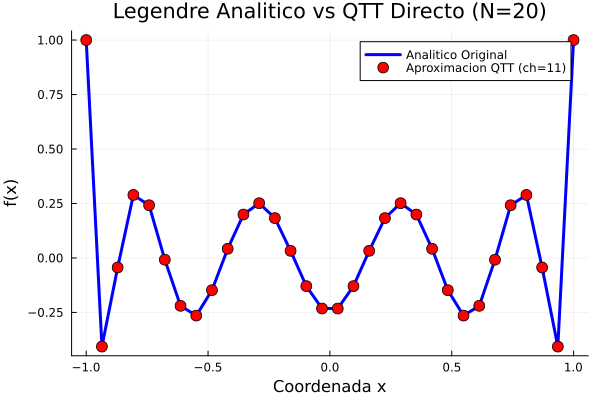

In [6]:
# --- CONFIGURACIÓN DEL MUESTREO PARA LA GRÁFICA ---
n_puntos_grafica = 32
# Generamos índices distribuidos uniformemente desde 0 hasta (dim_total - 1)
indices_grafica = [round(Int, i * (dim_total - 1) / (n_puntos_grafica - 1)) for i in 0:(n_puntos_grafica - 1)]

# Listas para almacenar los datos
x_vals = Float64[]
y_analitico = Float64[]
y_qtt = Float64[]

println("=== EVALUANDO $n_puntos_grafica PUNTOS PARA LA GRÁFICA ===")
for idx in indices_grafica
    # 1. Reconstruir la coordenada x real para este índice
    x = x_min
    for j in 1:N
        bit = (idx >> (j - 1)) & 1
        x += bit * dx * 2.0^(j - 1)
    end
    push!(x_vals, x)
    
    # 2. Calcular valor analítico real
    push!(y_analitico, Pl(x,n_Legendre))
    
    # 3. Extraer valor del QTT optimizado
    push!(y_qtt, evaluar_mps_en_punto(mps_optimizado, sites, idx))
end

# --- GENERACIÓN DE LA GRÁFICA ---
# Creamos el objeto del gráfico de la curva analítica
p = plot(x_vals, y_analitico, 
     label="Analitico Original", 
     linewidth=3, 
     linecolor=:blue, 
     title="Legendre Analitico vs QTT Directo (N=20)",
     xlabel="Coordenada x", 
     ylabel="f(x)",
     legend=:topright)

# Superponemos los puntos extraídos del QTT en el mismo objeto 'p'
scatter!(p, x_vals, y_qtt, 
         label="Aproximacion QTT (ch=$(n_Legendre+1))", 
         markersize=6, 
         markercolor=:red, 
         markershape=:circle)

# --- CORRECCIÓN PARA JUPYTER ---
# Imprimimos primero el error
error_max = maximum(abs.(y_analitico .- y_qtt))
println("Evaluación completada. Error máximo en la gráfica: ", error_max)

# Forzamos a Jupyter a mostrar la gráfica pase lo que pase
display(p)

In [7]:
# --- GENERADOR DE COEFICIENTES POLINOMIOS DE CHEBYSHEV ---
# Devuelve el vector C de tamaño (n+1) para el polinomio T_n(x)
function coeficientes_polinomio_Chebyshev(n)
    # Inicializamos matrices para guardar los coeficientes de los pasos anteriores
    # Cada columna representa un polinomio T_k(x) en la base [1, x, x^2, ..., x^n]
    M = zeros(Float64, n + 1, n + 1)
    
    # Casos base:
    # T_0(x) = 1  -> Coeficiente de x^0 es 1
    M[1, 1] = 1.0 
    
    if n == 0
        return M[:, 1]
    end
    
    # T_1(x) = x  -> Coeficiente de x^1 es 1
    M[2, 2] = 1.0 
    
    if n == 1
        return M[:, 2]
    end
    
    # Bucle de recurrencia: T_{k+1}(x) = 2x*T_k(x) - T_{k-1}(x)
    for k in 2:n
        # 1. Multiplicar T_k por 2x (desplazar hacia abajo en el vector y multiplicar por 2)
        for i in 1:n
            M[i+1, k+1] = 2.0 * M[i, k]
        end
        
        # 2. Restar T_{k-1}
        for i in 1:(n+1)
            M[i, k+1] -= M[i, k-1]
        end
    end
    
    # La última columna contiene los coeficientes monomiales exactos de T_n(x)
    return M[:, n + 1]
end

coeficientes_polinomio_Chebyshev (generic function with 1 method)

In [8]:
# --- PARÁMETROS DE LA MALLA ULTRA-DENSA ---
N = 20                  # 20 qubits/bits
dim_total = 1 << N      # 2^20 = 1.048.576 puntos
x_min = -1
x_max = 1  
dx = (x_max - x_min) / dim_total  

n_Chebyshev = 10
sites = siteinds("Qubit", N)

println("=== EXPERIMENTO QTT DE ALTA ESCALA ===")
println("Puntos en la malla: ", dim_total)
println("Número de Qubits:   ", N)
println("-"^50)

# Ejecutamos la construcción (Toma milisegundos)
println("Generando MPS comprimido directamente...")
@time mps_Chebyshev = construir_polinomio_qtt(sites, x_min,dx, coeficientes_polinomio_Chebyshev(n_Chebyshev))

# ==========================================================
# COMPRESIÓN NUMÉRICA DEL RESULTADO
# ==========================================================
# Le pasamos un truncamiento numérico al MPS final para ver si el 
# algoritmo puede reordenar y optimizar la base todavía más.
println("-"^50)
println("Max Bond Dim del QTT generado:   ", maxlinkdim(mps_Chebyshev))
mps_optimizado = truncate!(mps_Chebyshev; cutoff=1e-15)
println("Max Bond Dim tras optimización:  ", maxlinkdim(mps_optimizado))

# Calculamos el número de parámetros reales en memoria RAM
num_parametros_qtt = 0
for tensor in mps_optimizado
    num_parametros_qtt += dim(tensor)  # 'dim' extrae el tamaño del espacio del tensor
end

println("\n=== COMPARATIVA DE MEMORIA REAL ===")
println("Elementos Vector Clásico:     ", dim_total, " (Floats)")
println("Elementos Guardados en QTT:   ", num_parametros_qtt, " (Floats)")
println("Factor de compresión real:    ", round(dim_total / num_parametros_qtt, digits=1), "x menos RAM")

println("\n=== CONTROL DE CALIDAD 1: MUESTREO DE PUNTOS ===")

# Función modificada y segura para extraer el valor de un MPS en un índice clásico
function evaluar_mps_en_punto(mps, sites, indice_clasico)
    # Copiamos el MPS para no alterar el original durante la proyección
    mps_temp = copy(mps)
    
    for j in 1:length(mps_temp)
        # Determinamos si el bit j está en 0 (estado 1) o 1 (estado 2)
        bit_val = ((indice_clasico >> (j - 1)) & 1) + 1
        
        # Creamos un proyector local puro tipo vector (1 en la posición del bit, 0 en la otra)
        proyector = ITensor(sites[j])
        proyector[sites[j] => bit_val] = 1.0
        
        # Contraemos el nodo local del MPS con el proyector para colapsar ese qubit
        mps_temp[j] = mps_temp[j] * proyector
    end
    
    # Al final, contraemos todos los enlaces virtuales remanentes para obtener el número escalar
    resultado = mps_temp[1]
    for j in 2:length(mps_temp)
        resultado *= mps_temp[j]
    end
    
    return scalar(resultado)
end

# Puntos a evaluar: Origen (i=0), Centro (i=dim_total/2), Final (i=dim_total-1)
indices_prueba = [0, div(dim_total, 4), div(dim_total, 2), 3*div(dim_total, 4),dim_total - 1]

for idx in indices_prueba
    # Reconstruimos la coordenada x real correspondiente a ese índice
    x = x_min
    for j in 1:N
        bit = (idx >> (j - 1)) & 1
        x += bit * dx * 2.0^(j - 1)
    end
    
    val_analitico = cos(n_Chebyshev*acos(x))
    val_qtt = evaluar_mps_en_punto(mps_optimizado, sites, idx)
    
    println("En x = ", round(x, digits=4), " -> Real: ", val_analitico, " | QTT: ", val_qtt)
end

=== EXPERIMENTO QTT DE ALTA ESCALA ===
Puntos en la malla: 1048576
Número de Qubits:   20
--------------------------------------------------
Generando MPS comprimido directamente...
  0.056234 seconds (41.82 k allocations: 7.533 MiB, 98.56% compilation time)
--------------------------------------------------
Max Bond Dim del QTT generado:   11
Max Bond Dim tras optimización:  8

=== COMPARATIVA DE MEMORIA REAL ===
Elementos Vector Clásico:     1048576 (Floats)
Elementos Guardados en QTT:   740 (Floats)
Factor de compresión real:    1417.0x menos RAM

=== CONTROL DE CALIDAD 1: MUESTREO DE PUNTOS ===
En x = -1.0 -> Real: 1.0 | QTT: 0.9999997914214682
En x = -0.5 -> Real: -0.5000000000000034 | QTT: -0.5000000100669959
En x = 0.0 -> Real: -1.0 | QTT: -0.9999999871474363
En x = 0.5 -> Real: -0.4999999999999983 | QTT: -0.5000000220366672
En x = 1.0 -> Real: 0.9998092711393105 | QTT: 0.9998090595547716


=== EVALUANDO 32 PUNTOS PARA LA GRÁFICA ===
Evaluación completada. Error máximo en la gráfica: 2.1158453888947548e-7


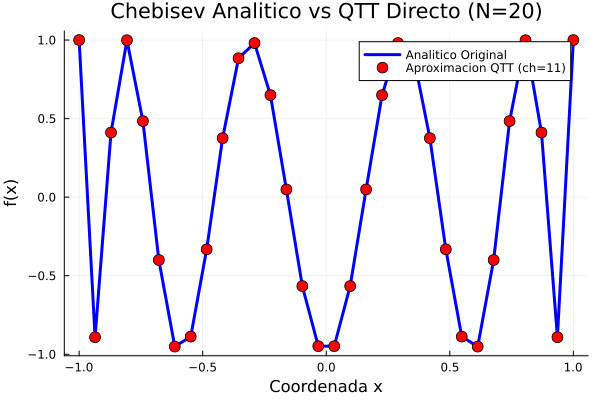

In [9]:
# --- CONFIGURACIÓN DEL MUESTREO PARA LA GRÁFICA ---
n_puntos_grafica = 32
# Generamos índices distribuidos uniformemente desde 0 hasta (dim_total - 1)
indices_grafica = [round(Int, i * (dim_total - 1) / (n_puntos_grafica - 1)) for i in 0:(n_puntos_grafica - 1)]

# Listas para almacenar los datos
x_vals = Float64[]
y_analitico = Float64[]
y_qtt = Float64[]

println("=== EVALUANDO $n_puntos_grafica PUNTOS PARA LA GRÁFICA ===")
for idx in indices_grafica
    # 1. Reconstruir la coordenada x real para este índice
    x = x_min
    for j in 1:N
        bit = (idx >> (j - 1)) & 1
        x += bit * dx * 2.0^(j - 1)
    end
    push!(x_vals, x)
    
    # 2. Calcular valor analítico real
    push!(y_analitico,cos(n_Chebyshev*acos(x)))
    
    # 3. Extraer valor del QTT optimizado
    push!(y_qtt, evaluar_mps_en_punto(mps_optimizado, sites, idx))
end

# --- GENERACIÓN DE LA GRÁFICA ---
# Creamos el objeto del gráfico de la curva analítica
p = plot(x_vals, y_analitico, 
     label="Analitico Original", 
     linewidth=3, 
     linecolor=:blue, 
     title="Chebisev Analitico vs QTT Directo (N=20)",
     xlabel="Coordenada x", 
     ylabel="f(x)",
     legend=:topright)

# Superponemos los puntos extraídos del QTT en el mismo objeto 'p'
scatter!(p, x_vals, y_qtt, 
         label="Aproximacion QTT (ch=$(n_Chebyshev+1))", 
         markersize=6, 
         markercolor=:red, 
         markershape=:circle)

# --- CORRECCIÓN PARA JUPYTER ---
# Imprimimos primero el error
error_max = maximum(abs.(y_analitico .- y_qtt))
println("Evaluación completada. Error máximo en la gráfica: ", error_max)

# Forzamos a Jupyter a mostrar la gráfica pase lo que pase
display(p)